# 이미지 데이터 분석기
각종 기능 등 테스트

## 1. 시각화 그래프 테스트

* 임베딩 벡터 분포 히스토그램
* 클러스터링 시각화

### 분포 히스토그램

In [25]:
import os
import torch
import clip
from PIL import Image

directory = './test_data'
formats = ['jpg', 'png', 'jpeg']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/16", device=device)
embeddings = []
filepath_list = []

file_count = 0
for root, _, files in os.walk(directory):
            for file in files:
                if file.endswith(tuple(formats)):
                    file_count += 1
                    file_path = os.path.join(root, file)
                    filepath_list.append(file_path)
                    with Image.open(file_path) as img:
                        with torch.no_grad():
                            input = preprocess(img).unsqueeze(0).to(device)
                            embedding = model.encode_image(input).cpu().numpy().flatten()
                            embeddings.append(embedding.tolist())

print(f"Total images processed: {file_count}")

Total images processed: 11


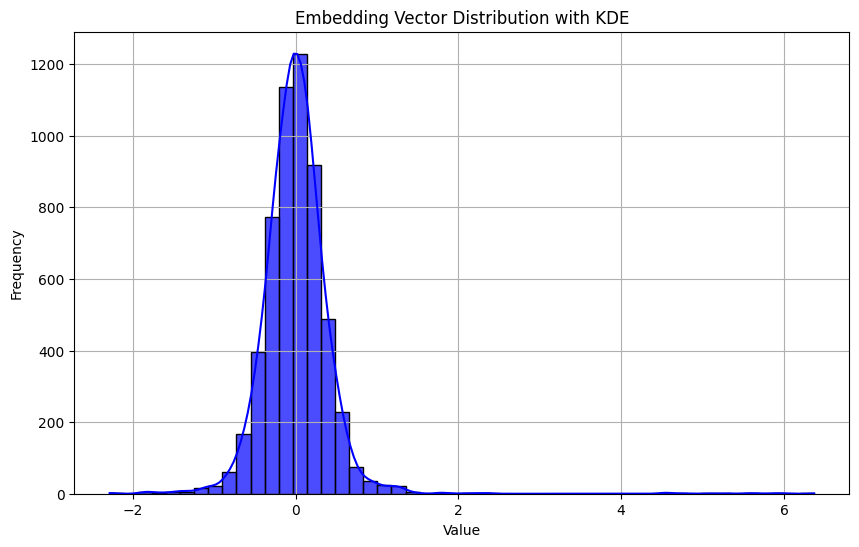

In [21]:
# 임베딩 벡터 분포 히스토그램 시각화
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Flatten the list of embeddings into a single array
flattened_embeddings = np.concatenate(embeddings)

plt.figure(figsize=(10, 6))
sns.histplot(flattened_embeddings, bins=50, color='blue', alpha=0.7, kde=True)
plt.title('Embedding Vector Distribution with KDE')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

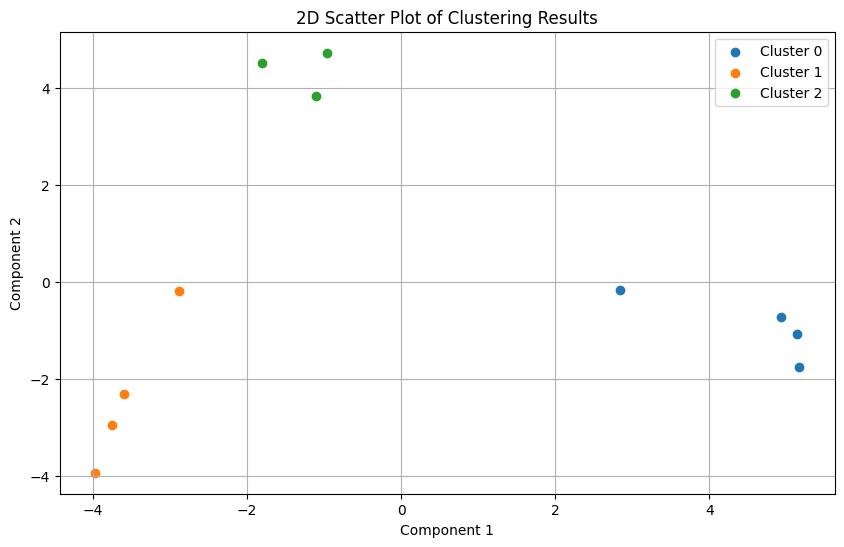

In [29]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 차원 축소
embeddings_array = np.array(embeddings)
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings_array)

# K-Means 클러스터링
num_clusters = 3  # 클러스터 개수 설정
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(reduced_embeddings)

# 클러스터링 결과 시각화
plt.figure(figsize=(10, 6))
for i in range(num_clusters):
    cluster_points = reduced_embeddings[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i}')
plt.title('2D Scatter Plot of Clustering Results')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()
plt.grid(True)
plt.show()

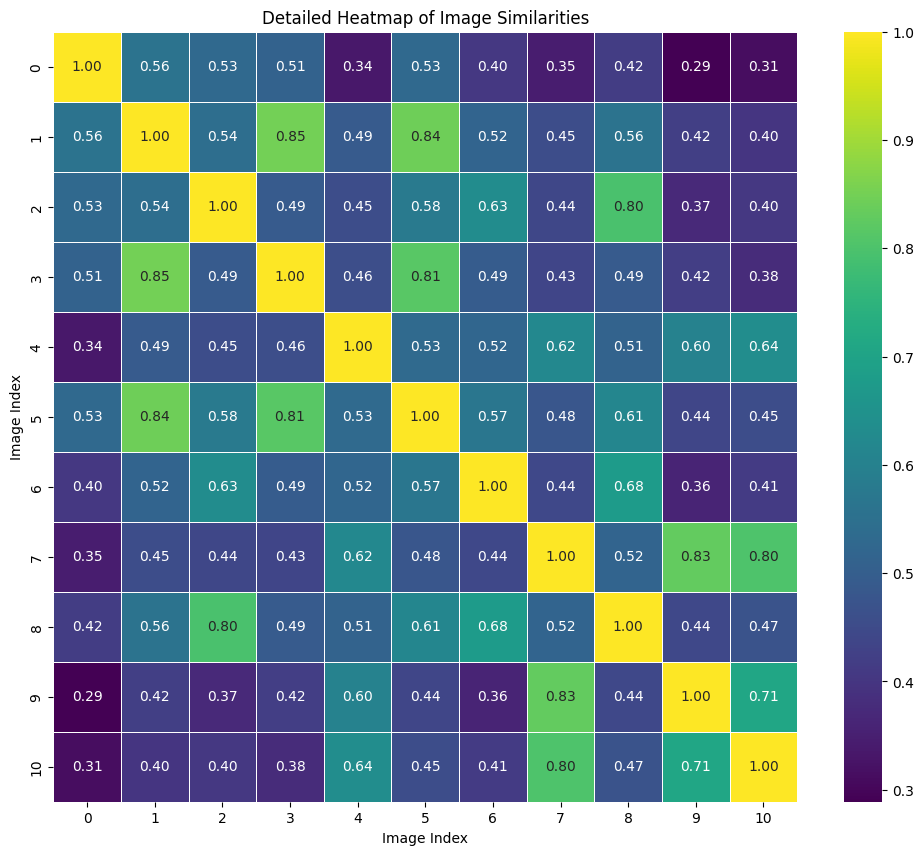

In [26]:
from sklearn.metrics.pairwise import cosine_similarity

# 유사도 계산
embeddings_array = np.array(embeddings)
similarity_matrix = cosine_similarity(embeddings_array)

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(similarity_matrix, cmap='viridis', cbar=True, annot=True, fmt=".2f", linewidths=0.5)
plt.title('Detailed Heatmap of Image Similarities')
plt.xlabel('Image Index')
plt.ylabel('Image Index')
plt.show()

Image 1 and Image 3 have similarity: 0.85


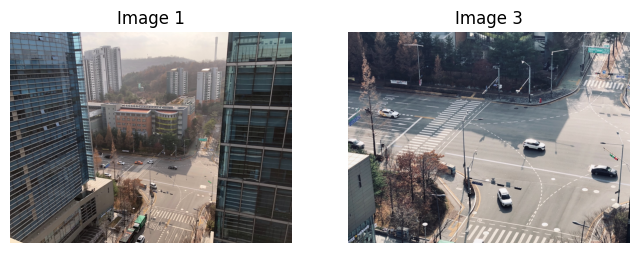

Image 1 and Image 5 have similarity: 0.84


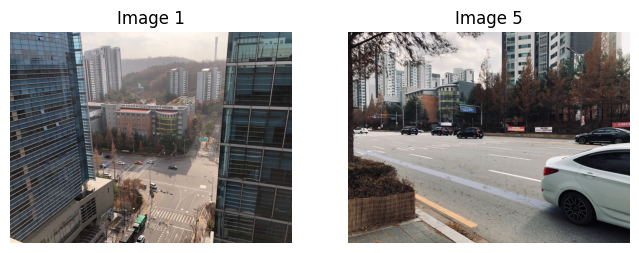

Image 3 and Image 5 have similarity: 0.81


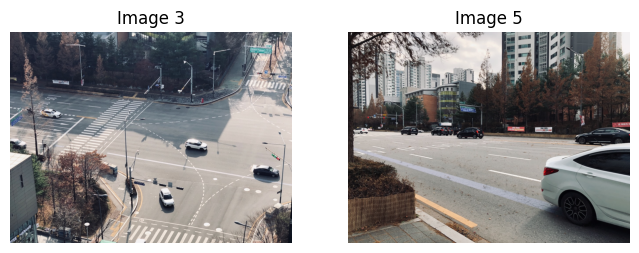

Image 7 and Image 9 have similarity: 0.83


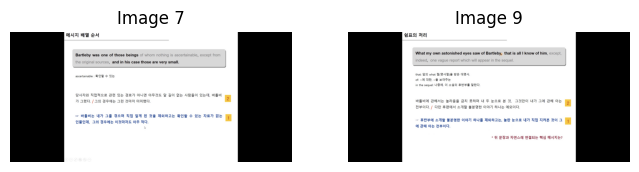

Image 7 and Image 10 have similarity: 0.80


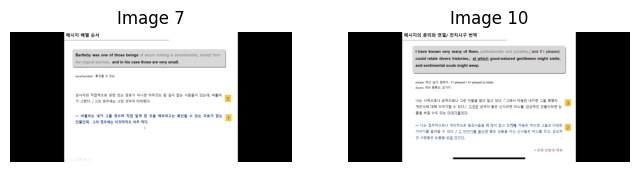

In [27]:
# 유사도가 0.8 이상인 이미지 쌍 출력
threshold = 0.8
similar_pairs = []

for i in range(len(similarity_matrix)):
    for j in range(i + 1, len(similarity_matrix)):  # 자기 자신 제외
        if similarity_matrix[i, j] >= threshold:
            similar_pairs.append((i, j, similarity_matrix[i, j]))

# 이미지 쌍 표시
for pair in similar_pairs:
    idx1, idx2, sim = pair
    print(f"Image {idx1} and Image {idx2} have similarity: {sim:.2f}")
    
    # 이미지 로드 및 표시
    img1 = Image.open(filepath_list[idx1])
    img2 = Image.open(filepath_list[idx2])
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title(f"Image {idx1}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(f"Image {idx2}")
    plt.axis('off')
    
    plt.show()

## 2. Compare 기능 테스트

In [30]:
def calculate_mmd_batch(X, Y, batch_size=1000, gamma=None):
    batch_size = min(batch_size, min(len(X), len(Y)))
    
    if len(X) > batch_size:
        idx = np.random.choice(len(X), batch_size, replace=False)
        X = X[idx]
    if len(Y) > batch_size:
        idx = np.random.choice(len(Y), batch_size, replace=False)
        Y = Y[idx]
    
    if gamma is None:
        X_combined = np.vstack([X[:batch_size], Y[:batch_size]])
        pairwise_dists = np.sum((X_combined[:, np.newaxis] - X_combined) ** 2, axis=2)
        gamma = 1.0 / np.median(pairwise_dists[pairwise_dists > 0])

    def kernel(X, Y):
        X_norm = np.sum(X ** 2, axis=1)
        Y_norm = np.sum(Y ** 2, axis=1)
        distances = X_norm[:, np.newaxis] + Y_norm - 2 * np.dot(X, Y.T)
        return np.exp(-gamma * distances)

    K_XX = kernel(X, X)
    K_YY = kernel(Y, Y)
    K_XY = kernel(X, Y)

    n_X = X.shape[0]
    n_Y = Y.shape[0]

    mmd = (np.sum(K_XX) - np.trace(K_XX)) / (n_X * (n_X - 1))
    mmd += (np.sum(K_YY) - np.trace(K_YY)) / (n_Y * (n_Y - 1))
    mmd -= 2 * np.mean(K_XY)

    return np.sqrt(max(mmd, 0))

In [121]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import os

def compare_datasets(directories):
    print(f"Comparing datasets in directories: {directories}")
    
    embeddings_list = []
    sizes_list = []
    resolutions_list = []
    noise_levels_list = []
    sharpness_list = []
    
    for directory in directories:
        cache_file = os.path.join(directory, 'logs', 'data_cache.json')
        if not os.path.exists(cache_file):
            print(f"No cache file found in {directory}")
            continue
        
        with open(cache_file, 'r') as f:
            cache = json.load(f)
        
        embeddings = [data['embedding'] for data in cache.values()]
        sizes = [data['size'] for data in cache.values()]
        resolutions = [data['resolution'] for data in cache.values()]
        noise_levels = [data['noise_level'] for data in cache.values()]
        sharpness = [data['sharpness'] for data in cache.values()]
        
        embeddings_list.append(np.array(embeddings))
        sizes_list.append(sizes)
        resolutions_list.append(resolutions)
        noise_levels_list.append(noise_levels)
        sharpness_list.append(sharpness)
    
    if len(embeddings_list) < 2:
        print("Not enough datasets to compare.")
        return
    
    # MMD 계산
    mmd_score = calculate_mmd_batch(embeddings_list[0], embeddings_list[1])
    print(f"MMD between datasets: {mmd_score:.4f}")
    
    # 임베딩 시각화
    pca = PCA(n_components=2)
    pca.fit(np.vstack(embeddings_list))
    
    transformed_data = [pca.transform(embeddings) for embeddings in embeddings_list]
    
    plt.figure(figsize=(12, 6))
    colors = ['blue', 'red']
    labels = ['Dataset 1', 'Dataset 2']
    
    for i, data in enumerate(transformed_data):
        plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label=labels[i], color=colors[i])
    
    plt.title('PCA of Embeddings')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.show()
    
    # 등고선 그래프
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for i, (data, ax) in enumerate(zip(transformed_data, axes)):
        # Calculate the point density
        x = data[:, 0]
        y = data[:, 1]
        xy = np.vstack([x, y])
        
        # Create a grid for contour plotting
        margin = 0.7  # 10% margin
        x_min, x_max = x.min() - margin * (x.max() - x.min()), x.max() + margin * (x.max() - x.min())
        y_min, y_max = y.min() - margin * (y.max() - y.min()), y.max() + margin * (y.max() - y.min())
        xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
        positions = np.vstack([xx.ravel(), yy.ravel()])
        
        # Calculate the density on the grid
        z = gaussian_kde(xy)(positions).reshape(xx.shape)
        
        ax.contourf(xx, yy, z, levels=20, cmap='YlGn', alpha=1)
        ax.contour(xx, yy, z, levels=20, colors='k', linewidths=0.5)
        ax.scatter(x, y, c='black', s=10, alpha=0.5)
        ax.set_title(f'Contour Plot of {labels[i]}')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()
    
    # 크기 분포
    plt.figure(figsize=(12, 6))
    for i, sizes in enumerate(sizes_list):
        sns.histplot(sizes, bins=30, label=f'Dataset {i+1}', color=colors[i], alpha=0.5)
    plt.title('Size Distribution (MB)')
    plt.xlabel('Size (MB)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    
    # 해상도 분포
    plt.figure(figsize=(12, 6))
    for i, resolutions in enumerate(resolutions_list):
        unique_res, counts = np.unique(resolutions, return_counts=True)
        plt.bar(unique_res, counts, label=f'Dataset {i+1}', alpha=0.5, color=colors[i])
    plt.title('Resolution Distribution')
    plt.xlabel('Resolution')
    plt.ylabel('Count')
    plt.legend()
    plt.show()
    
    # 노이즈 레벨 분포
    plt.figure(figsize=(12, 6))
    for i, noise_levels in enumerate(noise_levels_list):
        sns.histplot(noise_levels, bins=30, label=f'Dataset {i+1}', color=colors[i], alpha=0.5)
    plt.title('Noise Level Distribution')
    plt.xlabel('Noise Level')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    
    # 선명도 분포
    plt.figure(figsize=(12, 6))
    for i, sharpness in enumerate(sharpness_list):
        sns.histplot(sharpness, bins=30, label=f'Dataset {i+1}', color=colors[i], alpha=0.5)
    plt.title('Sharpness Distribution')
    plt.xlabel('Sharpness')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

Comparing datasets in directories: ['datasets/test_data3/', 'datasets/test_data4/']
MMD between datasets: 0.8442


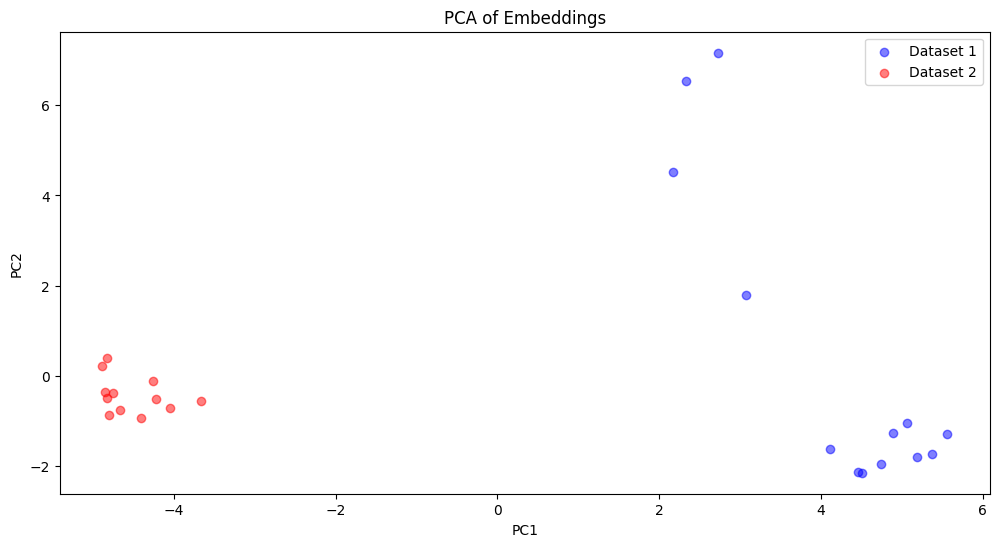

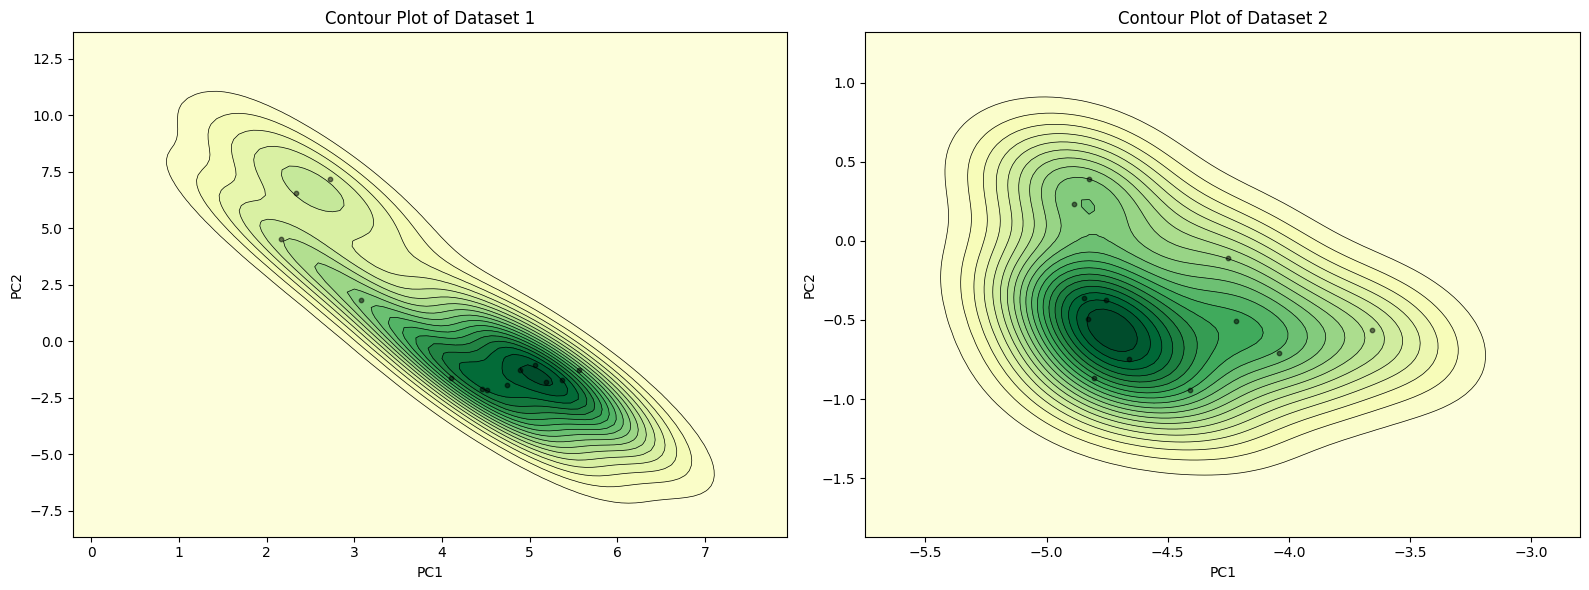

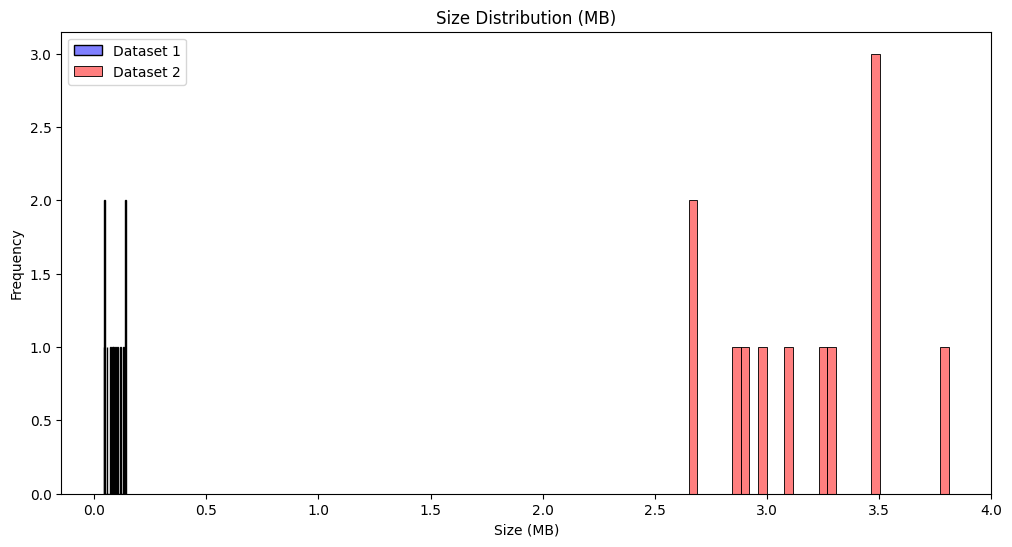

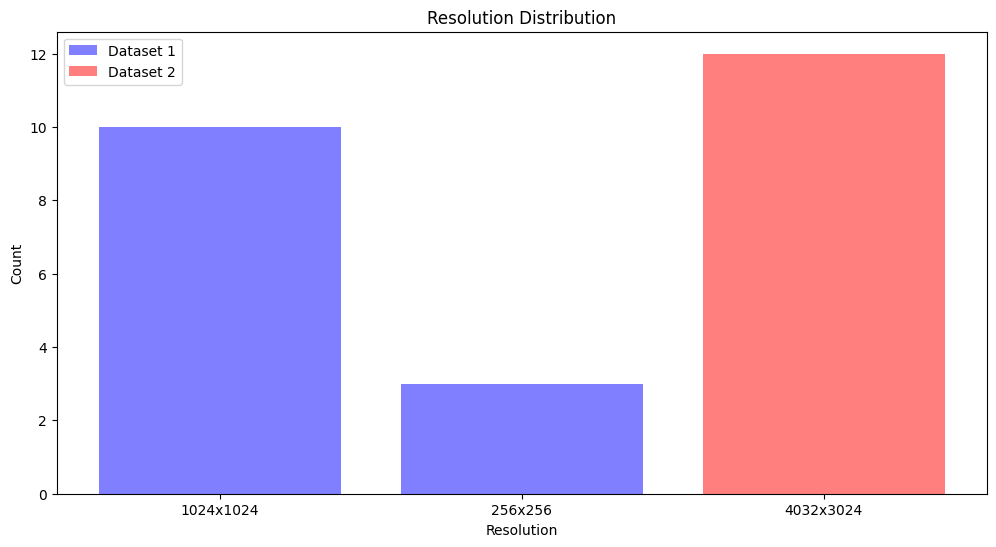

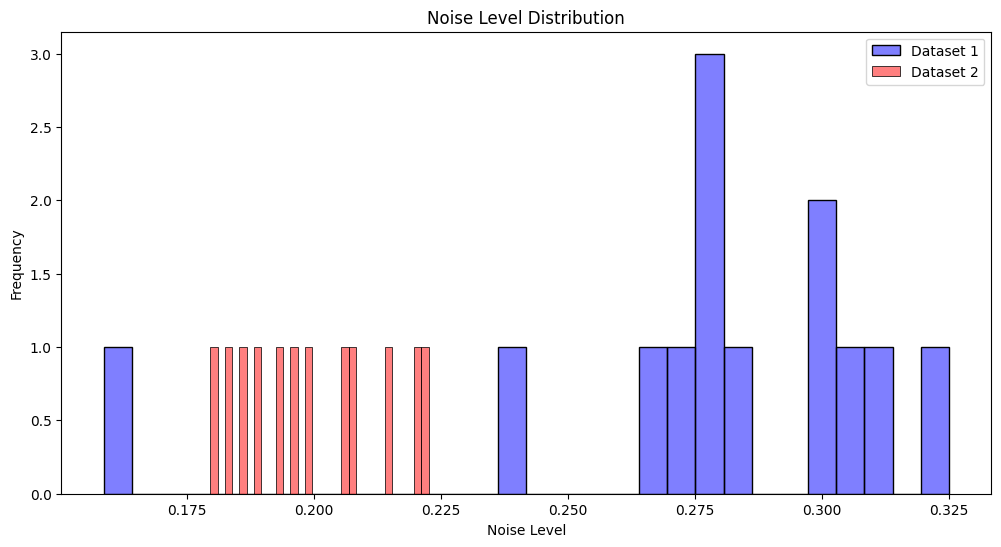

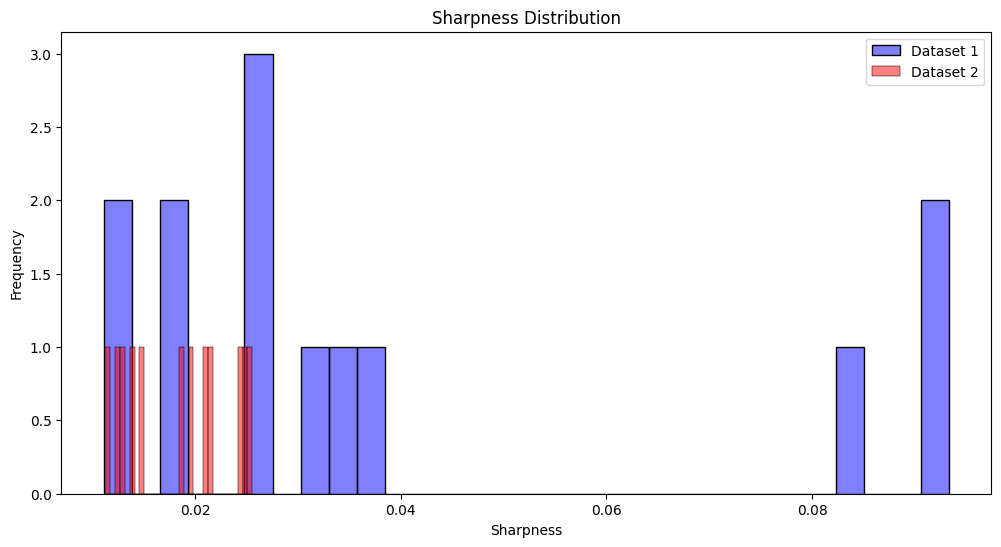

In [122]:
dir1_path = 'datasets/test_data3/'
dir2_path = 'datasets/test_data4/'

compare_datasets([dir1_path, dir2_path])

## 3. 모델 - 데이터 품질 평가 기능 테스트

설명 가능한 모델 인식 성능, feature localization, 데이터 품질 / 해석 가능성 / 공간 왜곡 / 통계적 특성 평가

### 3-1. Grad-CAM

Learning Deep Features for Discriminative Localization

#### PytorcHub ResNet 모델 테스트

In [150]:
import torch
from torch import nn
from torchvision.transforms import Compose, Normalize, ToTensor
import torch.nn.functional as F
from torch.autograd import Function
import torchvision.models as models

from pytorch_grad_cam import GradCAM, AblationCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import cv2
import numpy as np
from typing import List, Dict
import matplotlib.pyplot as plt
import timm
import os
import time
from PIL import Image

model = torch.hub.load("pytorch/vision", "resnet18", weights="ResNet18_Weights.IMAGENET1K_V1")
model

Using cache found in /Users/bhc/.cache/torch/hub/pytorch_vision_main


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [151]:
def preprocess_image(
    img: np.ndarray, mean=[
        0.5, 0.5, 0.5], std=[
            0.5, 0.5, 0.5]) -> torch.Tensor:
    preprocessing = Compose([
        ToTensor(),
        Normalize(mean=mean, std=std)
    ])
    return preprocessing(img.copy()).unsqueeze(0)

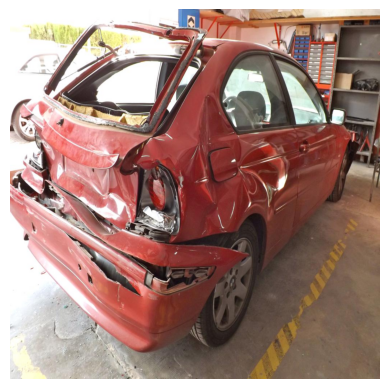

In [152]:
test_img = cv2.imread("datasets/test_data3/cardmg_2.jpg", 1)[:, :, ::-1]
plt.imshow(test_img)
plt.axis('off')  # Hide the axis
plt.show()

In [153]:
test_img = cv2.resize(test_img, (342, 342))
test_img = np.float32(test_img) / 255 #shape: (342, 342, 3)

input_tensor = preprocess_image(test_img,
                                mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])

input_tensor

tensor([[[[ 2.2489,  2.2489,  2.2489,  ...,  1.6838,  1.7180,  1.7523],
          [ 2.2489,  2.2489,  2.2489,  ...,  1.6495,  1.6667,  1.6667],
          [ 2.2489,  2.2489,  2.2489,  ...,  1.5810,  1.5810,  1.5639],
          ...,
          [ 1.8722,  1.8208,  1.8037,  ...,  0.0227, -0.0287,  0.0056],
          [ 1.8722,  1.8722,  1.7694,  ...,  0.0227,  0.0227,  0.1083],
          [ 1.9064,  1.7180,  1.6838,  ...,  0.0569,  0.0227,  0.0569]],

         [[ 2.4286,  2.4286,  2.4286,  ...,  1.6232,  1.6583,  1.6933],
          [ 2.4286,  2.4286,  2.4286,  ...,  1.6057,  1.6232,  1.6232],
          [ 2.4286,  2.4286,  2.4286,  ...,  1.5357,  1.5357,  1.5182],
          ...,
          [ 2.0434,  1.9909,  1.9734,  ..., -0.2500, -0.3025, -0.3200],
          [ 2.0434,  2.0434,  1.9384,  ..., -0.2500, -0.2500, -0.2150],
          [ 2.0784,  1.8859,  1.8508,  ..., -0.2150, -0.2500, -0.2675]],

         [[ 2.6400,  2.6400,  2.6400,  ...,  1.6814,  1.7163,  1.7511],
          [ 2.6400,  2.6400,  

In [154]:
layer = model.layer4
car_classes = [407, 436, 511, 817, 751, 656]

# cam 생성 및 처리
cam = AblationCAM(model=model, target_layers=[layer])
cam.batch_size = 1

# targets 설정 (클래스 인덱스)
targets = [ClassifierOutputTarget(class_id) for class_id in car_classes]

# grad-cam 계산
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0, :]

100%|██████████| 512/512 [00:09<00:00, 56.75it/s]


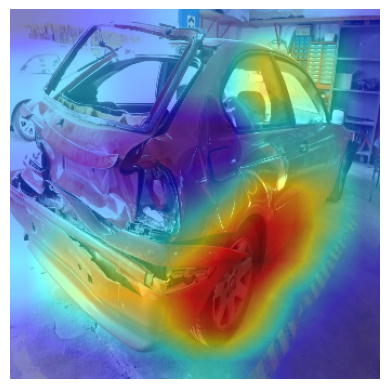

In [155]:
# 시각화
visualization = show_cam_on_image(test_img, grayscale_cam, use_rgb=True)
plt.imshow(visualization)
plt.axis('off')
plt.show()

#### PytorchHub YOLOv5 모델 테스트

In [11]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
import torch    
import cv2
import numpy as np
import requests
import torchvision.transforms as transforms
from pytorch_grad_cam import EigenCAM, EigenGradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, scale_cam_image
from PIL import Image

COLORS = np.random.uniform(0, 255, size=(80, 3))

def parse_detections(results):
    detections = results.pandas().xyxy[0]
    detections = detections.to_dict()
    boxes, colors, names = [], [], []

    for i in range(len(detections["xmin"])):
        confidence = detections["confidence"][i]
        if confidence < 0.2:
            continue
        xmin = int(detections["xmin"][i])
        ymin = int(detections["ymin"][i])
        xmax = int(detections["xmax"][i])
        ymax = int(detections["ymax"][i])
        name = detections["name"][i]
        category = int(detections["class"][i])
        color = COLORS[category]

        boxes.append((xmin, ymin, xmax, ymax))
        colors.append(color)
        names.append(name)
    return boxes, colors, names

def draw_detections(boxes, colors, names, img):
    for box, color, name in zip(boxes, colors, names):
        xmin, ymin, xmax, ymax = box
        cv2.rectangle(
            img,
            (xmin, ymin),
            (xmax, ymax),
            color, 
            2)

        cv2.putText(img, name, (xmin, ymin - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2,
                    lineType=cv2.LINE_AA)
 
    return img

In [2]:
# YOLOv5 모델 로드
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

Using cache found in /Users/bhc/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-4-14 Python-3.12.5 torch-2.6.0 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [28]:
img_path = 'datasets/test_data2/carnorm_8.jpg'
img = np.array(Image.open(img_path))
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255
transform = transforms.ToTensor()
tensor = transform(img).unsqueeze(0)

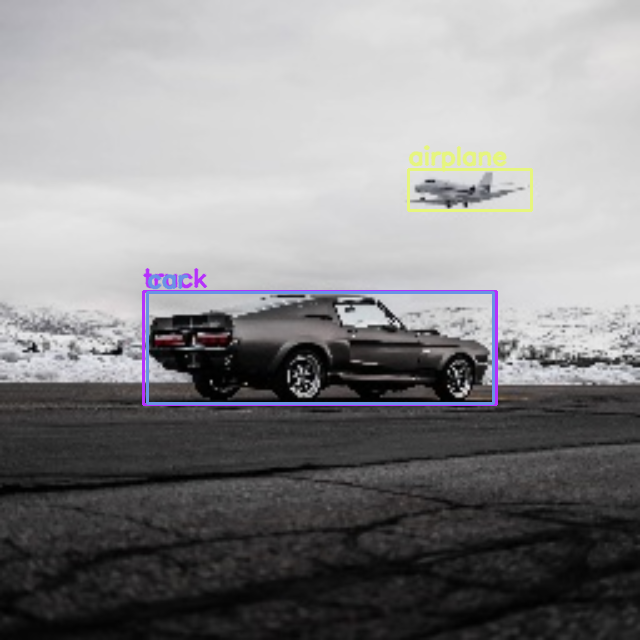

In [29]:
model.eval()
model.cpu()
target_layers = [model.model.model.model[-2]]

results = model([rgb_img])
boxes, colors, names = parse_detections(results)
detections = draw_detections(boxes, colors, names, rgb_img.copy())
Image.fromarray(detections)

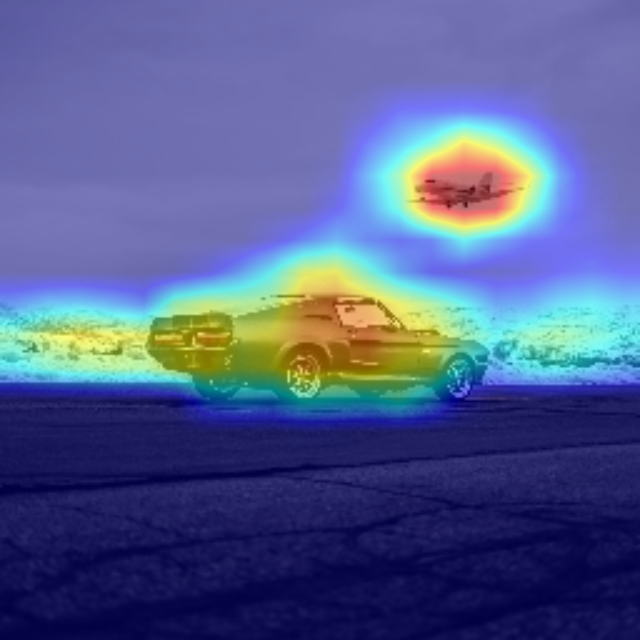

In [31]:
cam = EigenCAM(model, target_layers)
grayscale_cam = cam(tensor)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
Image.fromarray(cam_image)

#### ultralytics YOLOv8, YOLOv11 모델 테스트

In [2]:
from ultralytics import YOLO

from yolo_cam.eigen_cam import EigenCAM as YOLO_EigenCAM
from yolo_cam.utils.image import show_cam_on_image as show_yolocam_on_image
from yolo_cam.utils.image import scale_cam_image as scale_yolocam_image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

In [16]:
def parse_detections(results):
    """YOLO 모델의 결과를 박스, 색상, 클래스명으로 파싱"""
    boxes = []
    colors = []
    names = []
    
    for result in results[0].boxes:
        box = result.xyxy[0].cpu().numpy()  # x1, y1, x2, y2 형식
        conf = float(result.conf)
        cls = int(result.cls)
        name = results[0].names[cls]
        
        boxes.append(box)
        colors.append(generate_color(cls))  # 클래스별 고유 색상
        names.append(f"{name} {conf:.2f}")
    
    return np.array(boxes), colors, names

def generate_color(class_id):
    """클래스 ID에 따른 고유한 색상 생성"""
    np.random.seed(class_id)
    color = np.random.randint(0, 255, size=3).tolist()
    return color

def draw_detections(boxes, colors, names, image):
    """검출 결과를 이미지에 시각화"""
    for box, color, name in zip(boxes, colors, names):
        x1, y1, x2, y2 = map(int, box)
        
        # 박스 그리기
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        
        # 텍스트 배경 그리기
        (text_w, text_h), _ = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(image, (x1, y1-text_h-4), (x1+text_w, y1), color, -1)
        
        # 텍스트 그리기
        cv2.putText(image, name, (x1, y1-4), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)
    
    return image

In [17]:
img_path = 'datasets/test_data2/carnorm_6.jpg'
img = np.array(Image.open(img_path))
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255


0: 640x640 1 car, 91.3ms
Speed: 1.5ms preprocess, 91.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


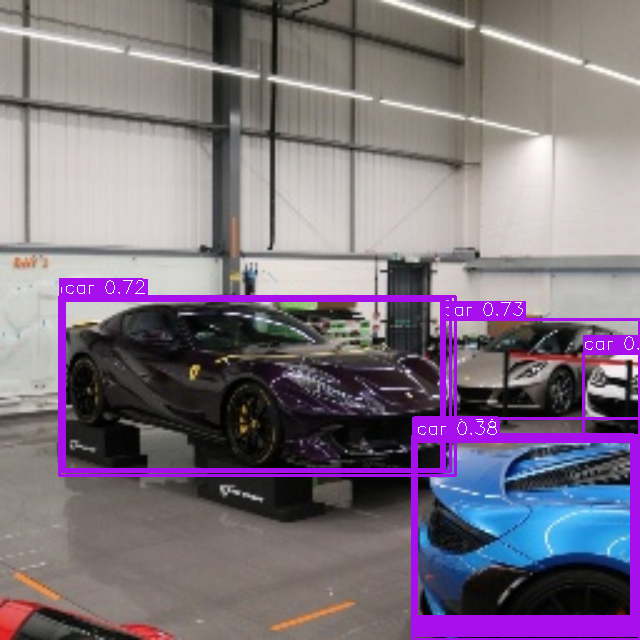

In [79]:
model = YOLO("yolov8n.pt")
model  = model.cpu()

results = model(rgb_img)
boxes, colors, names = parse_detections(results)
detections = draw_detections(boxes, colors, names, rgb_img)
display(Image.fromarray(detections))


0: 640x640 1 car, 91.0ms
Speed: 1.8ms preprocess, 91.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


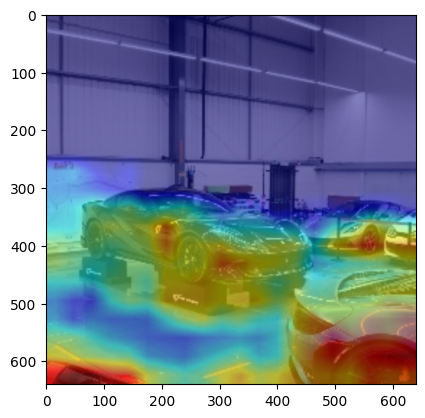

In [81]:
%matplotlib inline

target_layers = [model.model.model[20]]

cam = YOLO_EigenCAM(model, target_layers, task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_yolocam_on_image(img, grayscale_cam, use_rgb=True)

plt.imshow(cam_image)
plt.show()

23

0: 640x640 2 cars, 88.9ms
Speed: 1.5ms preprocess, 88.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


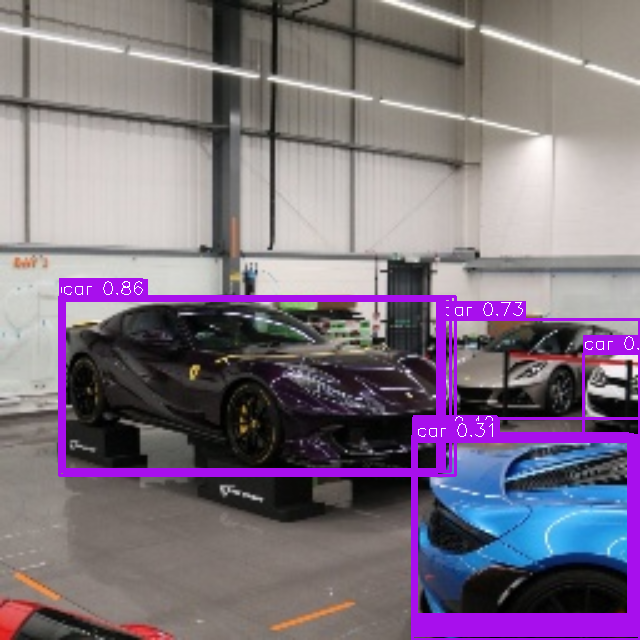

In [98]:
model = YOLO("../models/yolo11n.pt")
device = torch.device('cpu')
model.to(device)
print(len(model.model.model) - 1)

results = model(rgb_img)
boxes, colors, names = parse_detections(results)
detections = draw_detections(boxes, colors, names, rgb_img)
display(Image.fromarray(detections))

In [99]:
type(model.model.model[21])

ultralytics.nn.modules.conv.Concat


0: 640x640 2 cars, 89.0ms
Speed: 1.9ms preprocess, 89.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


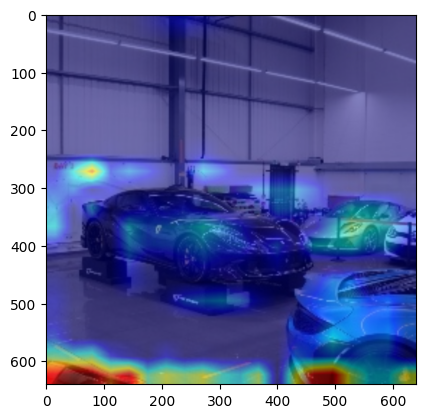

In [118]:
target_layers = [model.model.model[22]]

cam = YOLO_EigenCAM(model, target_layers, task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_yolocam_on_image(img, grayscale_cam, use_rgb=True)

plt.imshow(cam_image)
plt.show()

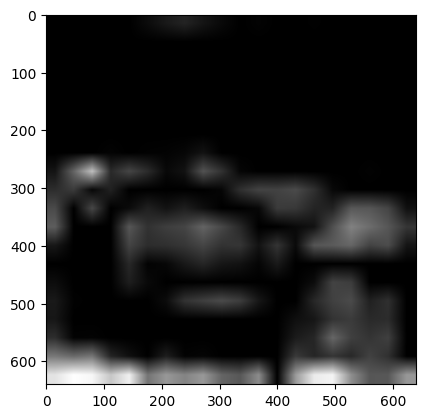

In [112]:
g_scale = cv2.resize(np.stack([grayscale_cam] * 3, axis=2), (640, 640))

plt.imshow(g_scale)
plt.show()

In [ ]:
# cv2.imwrite('g_scale.jpg', g_scale)
# >> [ WARN:0@425059.970] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.

In [114]:
g_scale_normalized = (grayscale_cam * 255).astype(np.uint8)
g_scale = cv2.resize(np.stack([g_scale_normalized] * 3, axis=2), (640, 640))

cv2.imwrite('g_scale.jpg', g_scale)

True

In [39]:
def visualize_layer_depth_sequence(model, img_path, start_depth=2, n_layers=10):
    # 이미지 로드 및 전처리
    img = np.array(Image.open(img_path))
    img = cv2.resize(img, (640, 640))
    rgb_img = img.copy()
    img = np.float32(img) / 255
    
    # 깊이 순서: -11(얕은 층)부터 -2(깊은 층)까지
    depths = range(start_depth + n_layers - 1, start_depth - 1, -1)
    
    # 메인 플롯 생성
    fig = plt.figure(figsize=(20, 8))
    gs = plt.GridSpec(2, 1, height_ratios=[0.2, 1], hspace=0.3)
    
    # 깊이 표시 컬러바 추가
    ax_depth = fig.add_subplot(gs[0])
    gradient = np.linspace(0, 1, 100).reshape(1, -1)
    ax_depth.imshow(gradient, cmap='Blues', aspect='auto')
    ax_depth.set_xticks([0, 99])
    ax_depth.set_xticklabels(['Shallow', 'Deep'])
    ax_depth.set_yticks([])
    ax_depth.set_title('Layer Depth', pad=10)
    
    # 각 레이어의 CAM 생성 및 시각화
    for idx, depth in enumerate(depths):
        try:
            target_layer = model.model.model[-depth]
            
            cam = YOLO_EigenCAM(model, [target_layer], task='od')
            grayscale_cam = cam(rgb_img)[0, :, :]
            cam_image = show_yolocam_on_image(img, grayscale_cam, use_rgb=True)
            
            ax = plt.subplot(1, n_layers, idx + 1)
            ax.imshow(cam_image)
            ax.set_title(f'Layer -{depth}')
            ax.axis('off')
        except Exception as e:
            print(f"Error processing layer at depth {depth}: {str(e)}")
            continue
    
    plt.suptitle('Layer-wise Visualization (Shallow → Deep)', y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()


0: 640x640 4 cars, 83.7ms
Speed: 1.9ms preprocess, 83.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 4 cars, 80.7ms
Speed: 1.4ms preprocess, 80.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 4 cars, 79.5ms
Speed: 1.3ms preprocess, 79.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 4 cars, 81.2ms
Speed: 1.7ms preprocess, 81.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 4 cars, 81.7ms
Speed: 1.5ms preprocess, 81.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 4 cars, 81.0ms
Speed: 1.3ms preprocess, 81.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 4 cars, 80.4ms
Speed: 1.3ms preprocess, 80.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 4 cars, 81.5ms
Speed: 1.4ms preprocess, 81.5ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x

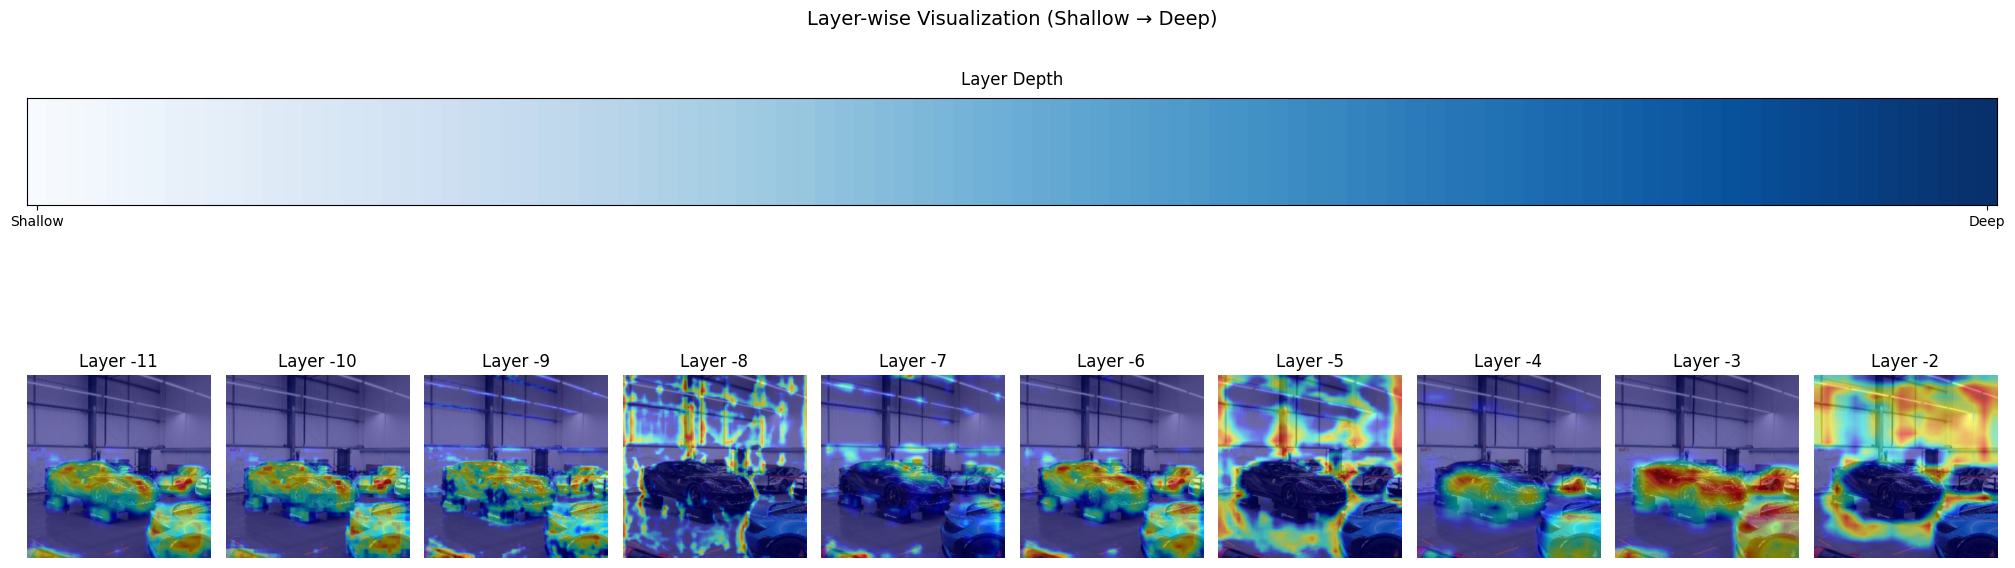

In [40]:
img_path = 'datasets/test_data2/carnorm_6.jpg'
model = YOLO("../models/yolo11n.pt")
model  = model.cpu()

visualize_layer_depth_sequence(model, img_path, start_depth=2, n_layers=10)

In [46]:
len(model.model.model) - 1

23

In [85]:
model.model.model[21]

Concat()

### 3-2. LIME

Local Interpretable Model-Agnostic Explanations

### 3-3. Image Data Evaluations

* SSIM : 이미지 쌍의 구조적 유사성 평가
* MSE : 이미지 쌍 평균 제곱 오차 계산 (낮을수록 고품질)
* NIQE : 비참조 방식 이미지 품질 평가
* BRISQUE : 비참조 방식 이미지 공간 왜곡 평가
* VIF : 이미지 쌍 왜곡 정도에 의한 시각적 정보 충실도 평가